# imports

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from torchvision.transforms import v2

# configs

In [2]:
ISKAGGLE = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')
RANDOMSEED = 1727

BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 1e-3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# reproducibility

torch.use_deterministic_algorithms(True)

def random_seed(seed=RANDOMSEED, use_cuda=False):
  np.random.seed(seed) # cpu vars
  torch.manual_seed(seed) # cpu vars
  random.seed(seed) # Python
  
  if use_cuda: 
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # gpu vars
    torch.backends.cudnn.deterministic = True  #needed
    torch.backends.cudnn.benchmark = False
    
random_seed()

# load data

In [4]:
from pathlib import Path

cred_path = Path('~/.kaggle/access_token').expanduser()
if not cred_path.exists():
  cred_path.parent.mkdir(exist_ok=True)
  cred_path.write_text("KGAT_9f6b15aaf6f7637b8497dfb3c56c079e")
  cred_path.chmod(0o600)

In [5]:
nname = Path('digit-recognizer')

if not ISKAGGLE:
  if not nname.exists():
    import zipfile,kaggle
    kaggle.api.authenticate()
    kaggle.api.competition_download_cli(str(nname))
    zipfile.ZipFile(f'{nname}.zip').extractall(nname)
else:
  # /kaggle/input/competitions/nlp-getting-started/train.csv
  nname = Path(f'/kaggle/input/competitions/{nname}')

# %pip install -q datasets
!dir /o:g /w {nname}
# !ls {nname}

 Volume in drive C is Windows
 Volume Serial Number is 6291-898F

 Directory of c:\Users\longnuub\learning-programming-languages\learning-python\kaggle\digit-recognizer

[..]                    [.]                     test.csv
train.csv               sample_submission.csv   
               3 File(s)    128.134.246 bytes
               2 Dir(s)  134.896.422.912 bytes free


# dataset

In [8]:
class DigitDataset(Dataset):
    def __init__(self, dataframe, labels=None, transform=None):
        self.dataframe = dataframe
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image = self.dataframe.iloc[idx].values.astype(np.float32)
        image /= 255.0 # normalize
        image = image.reshape(1, 28, 28) # reshape to (C,H,W)
        image = torch.tensor(image, dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        if self.labels is not None:
            label = torch.tensor(self.labels.iloc[idx], dtype=torch.long)
            return image, label

        return image

load csv

In [10]:
train=pd.read_csv(nname/"train.csv")
test=pd.read_csv(nname/"test.csv")

# drop the `id` col for training data ONLY, we need the id for test preds later
# train.drop(columns=["id"],inplace=True)

In [18]:
xtrain=train.copy().drop(columns="label")
ytrain=train["label"]

visualize

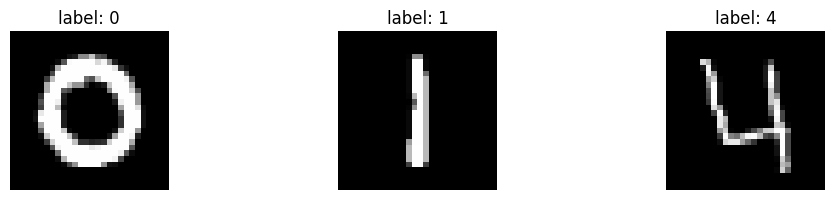

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))
for i in range(1,4):
    plt.subplot(3,3,i)
    plt.imshow(xtrain.iloc[i].values.reshape(28,28),cmap="gray")
    plt.title("label: " + str(ytrain[i]))
    plt.axis(False)

image augmentation

In [22]:
trs = v2.Compose([
    v2.RandomRotation(10),
    v2.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        shear=3,
        scale=(0.92, 1.08),
        fill=0,
    ),
])

dataloaders

In [23]:
full_dataset = DigitDataset(xtrain,ytrain,transform=trs)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(RANDOMSEED)
)

train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)

test_dataset = DigitDataset(test)
test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False)

# model code

cnn class code

In [24]:
class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # block 1
            nn.Conv2d(1, 32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # block 2
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 5 * 5, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x

model = DigitCNN().to(DEVICE)

loss/optimizers/schedulers

In [27]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    threshold=0.001,
    min_lr=0.00001,
)

# training loop

In [28]:
best_val_loss = float("inf")
patience = 5
patience_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(EPOCHS):

    # =========================
    # TRAIN
    # =========================

    model.train()

    train_loss = 0
    train_correct = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = train_correct / len(train_dataset)

    # =========================
    # VALIDATION
    # =========================

    model.eval()

    val_loss = 0
    val_correct = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / len(val_dataset)
    scheduler.step(val_loss)

    # =========================
    # EARLY STOPPING LOGIC
    # =========================

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        patience_counter = 0
    else:
        patience_counter += 1

    # =========================
    # LOGGING
    # =========================

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if patience_counter >= patience:
        print("Early stopping triggered")
        break

Epoch 1/20 | Train Loss: 0.4098 | Val Loss: 0.1490 | Train Acc: 0.8707 | Val Acc: 0.9543
Epoch 2/20 | Train Loss: 0.1414 | Val Loss: 0.0944 | Train Acc: 0.9558 | Val Acc: 0.9710
Epoch 3/20 | Train Loss: 0.1121 | Val Loss: 0.0779 | Train Acc: 0.9657 | Val Acc: 0.9755
Epoch 4/20 | Train Loss: 0.0885 | Val Loss: 0.0727 | Train Acc: 0.9740 | Val Acc: 0.9768
Epoch 5/20 | Train Loss: 0.0816 | Val Loss: 0.0526 | Train Acc: 0.9755 | Val Acc: 0.9824
Epoch 6/20 | Train Loss: 0.0706 | Val Loss: 0.0543 | Train Acc: 0.9782 | Val Acc: 0.9829
Epoch 7/20 | Train Loss: 0.0641 | Val Loss: 0.0504 | Train Acc: 0.9800 | Val Acc: 0.9832
Epoch 8/20 | Train Loss: 0.0628 | Val Loss: 0.0413 | Train Acc: 0.9803 | Val Acc: 0.9868
Epoch 9/20 | Train Loss: 0.0562 | Val Loss: 0.0434 | Train Acc: 0.9821 | Val Acc: 0.9868
Epoch 10/20 | Train Loss: 0.0536 | Val Loss: 0.0450 | Train Acc: 0.9840 | Val Acc: 0.9851
Epoch 11/20 | Train Loss: 0.0492 | Val Loss: 0.0420 | Train Acc: 0.9853 | Val Acc: 0.9870
Epoch 12/20 | Train

<Axes: >

<Figure size 1200x700 with 0 Axes>

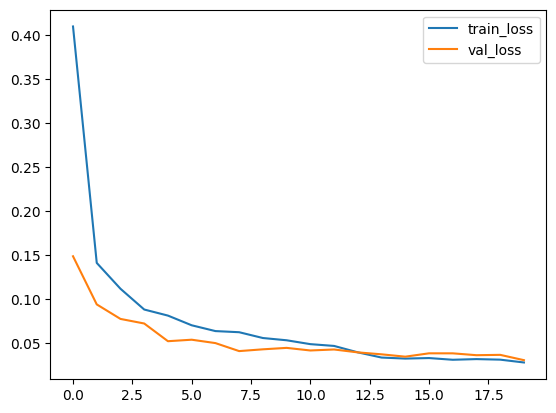

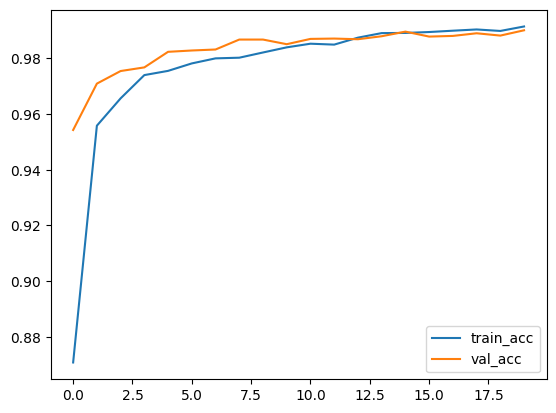

In [29]:
history_frame = pd.DataFrame(history)

plt.figure(figsize=(12,7))

history_frame.loc[:, ['train_loss', 'val_loss']].plot()
history_frame.loc[:, ['train_acc', 'val_acc']].plot()

# prediction

load best model

In [30]:
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

predict

In [31]:
model.eval()

predictions = []

with torch.no_grad():
    for images in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        predictions.extend(preds.cpu().numpy())

In [32]:
subs_df = pd.DataFrame({
    "ImageId": np.arange(1, len(predictions)+1),
    "Label": predictions
})

In [33]:
print(subs_df.head())
print(subs_df.shape)

   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      0
4        5      3
(28000, 2)


In [34]:
subs_df.to_csv("submission.csv", index=False)